# Spatial Object Selection Comparison

This notebook reformulates the task from **6-way grasp candidate ranking** into **3-way object classification**.

## What changes
- Keep the recorded spatial instructions unchanged, such as:
  - `Pick the carton on the left.`
  - `Pour from the carton in the center.`
- Predict the target **object identity** only:
  - `whole`
  - `oat`
  - `soy`
- Then map the predicted object back to the final grasp candidate:
  - `pickup -> <object>_top`
  - `pour -> <object>_side`

## Why this helps
The old 6-way setup had a built-in `1/3` shortcut baseline because the model could use:
- `pick -> top`
- `pour -> side`

This 3-way formulation removes that shortcut and better tests whether the image helps with spatial grounding.


In [20]:
# Optional install cell if needed.
# import sys
# !{sys.executable} -m pip install transformers accelerate sentencepiece protobuf==3.20.3


In [21]:
from pathlib import Path
import gc
import json
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoModel, AutoProcessor

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

In [22]:
PROJECT_ROOT = Path('/home/gyanig/catkin_ws/src/tabletop_workspace_opt')
DATA_ROOT = PROJECT_ROOT / 'data' / 'milk_candidate_cls'
SAMPLES_PATH = DATA_ROOT / 'candidate_samples_semantic_spatial.jsonl'

CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
SIGLIP_MODEL_NAME = 'google/siglip-base-patch16-224'
BATCH_SIZE = 4
EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

OBJECT_TO_INDEX = {'whole': 0, 'oat': 1, 'soy': 2}
INDEX_TO_OBJECT = {v: k for k, v in OBJECT_TO_INDEX.items()}

assert SAMPLES_PATH.exists(), SAMPLES_PATH


In [23]:
def load_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

full_df = pd.DataFrame(load_jsonl(SAMPLES_PATH))
df = full_df[full_df['episode_notes'] == 'spatial_prompt'].copy().reset_index(drop=True)
df.head(2)


,sample_id,episode_id,scene_id,view_id,image_path,instruction,correct_candidate_id,label,task_type,scene_notes,episode_notes,slot_assignment,candidate_id,object_short,object_name,grasp_type,grasp_description,task_suitability,candidate_text,candidate_text_reduced
0,milk_scene_01_top__semsp_001__whole_top,milk_scene_01_top__semsp_001,milk_scene_01_top,top,images/milk_scene_01_top.png,Pick the carton on the left.,whole_top,1,pickup,fixed layout v1; synthetic_semantic_spatial_pr...,spatial_prompt,"{'left': 'whole_milk', 'center': 'oat_milk', '...",whole_top,whole,whole_milk,top,top grasp,pickup,Object: whole_milk. Grasp: top grasp. Task sui...,Candidate grasp type: top grasp.
1,milk_scene_01_top__semsp_001__whole_side,milk_scene_01_top__semsp_001,milk_scene_01_top,top,images/milk_scene_01_top.png,Pick the carton on the left.,whole_top,0,pickup,fixed layout v1; synthetic_semantic_spatial_pr...,spatial_prompt,"{'left': 'whole_milk', 'center': 'oat_milk', '...",whole_side,whole,whole_milk,side,side grasp,pour,Object: whole_milk. Grasp: side grasp. Task su...,Candidate grasp type: side grasp.


In [24]:
def base_scene_id(scene_id: str) -> str:
    for suffix in ('_top', '_side', '_lean'):
        if scene_id.endswith(suffix):
            return scene_id[:-len(suffix)]
    return scene_id

def object_from_candidate_id(candidate_id: str) -> str:
    return candidate_id.split('_', 1)[0]


def final_candidate_from_object(object_short: str, task_type: str) -> str:
    grasp = 'top' if task_type == 'pickup' else 'side'
    return f'{object_short}_{grasp}'


df['base_scene_id'] = df['scene_id'].map(base_scene_id)
df['target_object'] = df['correct_candidate_id'].map(object_from_candidate_id)
df['target_object_index'] = df['target_object'].map(OBJECT_TO_INDEX)

df['text_instruction_only'] = df['instruction']
df['text_instruction_with_task'] = df.apply(
    lambda row: f"Instruction: {row['instruction']} Task type: {row['task_type']}", axis=1
)

print('rows:', len(df))
print('episodes:', df['episode_id'].nunique())
print('scene/views:', df['scene_id'].nunique())
print('base scenes:', sorted(df['base_scene_id'].unique()))
print(df[['instruction', 'task_type', 'correct_candidate_id', 'target_object']].head(8))


rows: 3240
episodes: 540
scene/views: 15
base scenes: ['milk_scene_01', 'milk_scene_02', 'milk_scene_03', 'milk_scene_04', 'milk_scene_05', 'scene_04']
                    instruction task_type correct_candidate_id target_object
0  Pick the carton on the left.    pickup            whole_top         whole
1  Pick the carton on the left.    pickup            whole_top         whole
2  Pick the carton on the left.    pickup            whole_top         whole
3  Pick the carton on the left.    pickup            whole_top         whole
4  Pick the carton on the left.    pickup            whole_top         whole
5  Pick the carton on the left.    pickup            whole_top         whole
6      Pick up the left carton.    pickup            whole_top         whole
7      Pick up the left carton.    pickup            whole_top         whole


In [25]:
base_scenes = sorted(df['base_scene_id'].unique())
assert len(base_scenes) >= 2, 'Need at least two base scenes for a scene split.'

val_scene_count = 2 if len(base_scenes) >= 4 else 1
train_scenes = base_scenes[:-val_scene_count]
val_scenes = base_scenes[-val_scene_count:]

train_df = df[df['base_scene_id'].isin(train_scenes)].reset_index(drop=True)
val_df = df[df['base_scene_id'].isin(val_scenes)].reset_index(drop=True)

print('train scenes:', train_scenes)
print('val scenes  :', val_scenes)
print('train rows   :', len(train_df))
print('val rows     :', len(val_df))
print('train episodes:', train_df['episode_id'].nunique())
print('val episodes  :', val_df['episode_id'].nunique())


train scenes: ['milk_scene_01', 'milk_scene_02', 'milk_scene_03', 'milk_scene_04']
val scenes  : ['milk_scene_05', 'scene_04']
train rows   : 2376
val rows     : 864
train episodes: 396
val episodes  : 144


In [26]:
def build_object_records(frame: pd.DataFrame, text_column='text_instruction_only'):
    records = []
    grouped = frame.groupby('episode_id', sort=True)
    for episode_id, g in grouped:
        g = g.reset_index(drop=True)
        row0 = g.iloc[0]
        records.append({
            'episode_id': episode_id,
            'scene_id': row0['scene_id'],
            'base_scene_id': row0['base_scene_id'],
            'view_id': row0['view_id'],
            'image_path': row0['image_path'],
            'instruction': row0[text_column],
            'task_type': row0['task_type'],
            'target_object': row0['target_object'],
            'target_index': int(row0['target_object_index']),
            'correct_candidate_id': row0['correct_candidate_id'],
        })
    return records

train_records = build_object_records(train_df, text_column='text_instruction_only')
val_records = build_object_records(val_df, text_column='text_instruction_only')

print('train object episodes:', len(train_records))
print('val object episodes  :', len(val_records))
train_records[0]


train object episodes: 396
val object episodes  : 144


{'episode_id': 'milk_scene_01_lean__semsp_055',
 'scene_id': 'milk_scene_01_lean',
 'base_scene_id': 'milk_scene_01',
 'view_id': 'lean',
 'image_path': 'images/milk_scene_01_lean.png',
 'instruction': 'Pick the carton on the left.',
 'task_type': 'pickup',
 'target_object': 'whole',
 'target_index': 0,
 'correct_candidate_id': 'whole_top'}

In [27]:
class TextOnlyObjectDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        return {
            'instruction': rec['instruction'],
            'target_index': rec['target_index'],
            'task_type': rec['task_type'],
            'correct_candidate_id': rec['correct_candidate_id'],
        }


class ImageTextObjectDataset(Dataset):
    def __init__(self, records, image_root):
        self.records = records
        self.image_root = image_root

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = Image.open(self.image_root / rec['image_path']).convert('RGB')
        return {
            'image': image,
            'instruction': rec['instruction'],
            'target_index': rec['target_index'],
            'task_type': rec['task_type'],
            'correct_candidate_id': rec['correct_candidate_id'],
        }


In [28]:
def get_image_features(model, pixel_values):
    if hasattr(model, 'get_image_features'):
        return model.get_image_features(pixel_values=pixel_values)
    return model.vision_model(pixel_values=pixel_values).pooler_output


def get_text_features(model, input_ids, attention_mask=None):
    if hasattr(model, 'get_text_features'):
        kwargs = {'input_ids': input_ids}
        if attention_mask is not None:
            kwargs['attention_mask'] = attention_mask
        return model.get_text_features(**kwargs)
    if attention_mask is not None:
        return model.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
    return model.text_model(input_ids=input_ids).pooler_output


def l2_normalize(x):
    return x / x.norm(dim=-1, keepdim=True).clamp_min(1e-6)


class TextOnlyObjectClassifier(nn.Module):
    def __init__(self, vlm_backbone, embed_dim, num_classes=3):
        super().__init__()
        self.vlm_backbone = vlm_backbone
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            text_feat = get_text_features(self.vlm_backbone, input_ids, attention_mask)
            text_feat = l2_normalize(text_feat)
        return self.classifier(text_feat)


class ImageTextObjectClassifier(nn.Module):
    def __init__(self, vlm_backbone, embed_dim, num_classes=3):
        super().__init__()
        self.vlm_backbone = vlm_backbone
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        with torch.no_grad():
            image_feat = get_image_features(self.vlm_backbone, pixel_values)
            text_feat = get_text_features(self.vlm_backbone, input_ids, attention_mask)
            image_feat = l2_normalize(image_feat)
            text_feat = l2_normalize(text_feat)
        joint = torch.cat([image_feat, text_feat, image_feat * text_feat], dim=1)
        return self.classifier(joint)


In [29]:
def collate_text_only(batch, processor):
    texts = [item['instruction'] for item in batch]
    text_inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    out = {
        'input_ids': text_inputs['input_ids'],
        'targets': torch.tensor([item['target_index'] for item in batch], dtype=torch.long),
        'task_types': [item['task_type'] for item in batch],
        'correct_candidate_ids': [item['correct_candidate_id'] for item in batch],
    }
    if 'attention_mask' in text_inputs:
        out['attention_mask'] = text_inputs['attention_mask']
    return out


def collate_image_text(batch, processor):
    images = [item['image'] for item in batch]
    texts = [item['instruction'] for item in batch]
    image_inputs = processor(images=images, return_tensors='pt')
    text_inputs = processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    out = {
        'pixel_values': image_inputs['pixel_values'],
        'input_ids': text_inputs['input_ids'],
        'targets': torch.tensor([item['target_index'] for item in batch], dtype=torch.long),
        'task_types': [item['task_type'] for item in batch],
        'correct_candidate_ids': [item['correct_candidate_id'] for item in batch],
    }
    if 'attention_mask' in text_inputs:
        out['attention_mask'] = text_inputs['attention_mask']
    return out


def metrics_from_predictions(pred_indices, targets, task_types, correct_candidate_ids):
    object_acc = sum(int(p == t) for p, t in zip(pred_indices, targets)) / max(len(targets), 1)
    pred_candidates = [
        final_candidate_from_object(INDEX_TO_OBJECT[p], task)
        for p, task in zip(pred_indices, task_types)
    ]
    candidate_acc = sum(int(p == gt) for p, gt in zip(pred_candidates, correct_candidate_ids)) / max(len(correct_candidate_ids), 1)
    return object_acc, candidate_acc


def run_text_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss = 0.0
    n = 0
    all_preds = []
    all_targets = []
    all_tasks = []
    all_gt_candidates = []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        targets = batch['targets'].to(device)
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, targets)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        pred = logits.argmax(dim=1)
        all_preds.extend(pred.detach().cpu().tolist())
        all_targets.extend(targets.detach().cpu().tolist())
        all_tasks.extend(batch['task_types'])
        all_gt_candidates.extend(batch['correct_candidate_ids'])
        n += len(targets)
        total_loss += float(loss.item()) * len(targets)
    object_acc, candidate_acc = metrics_from_predictions(all_preds, all_targets, all_tasks, all_gt_candidates)
    return {
        'loss': total_loss / max(n, 1),
        'object_top1': object_acc,
        'candidate_top1': candidate_acc,
    }


def run_image_text_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss = 0.0
    n = 0
    all_preds = []
    all_targets = []
    all_tasks = []
    all_gt_candidates = []
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)
        targets = batch['targets'].to(device)
        logits = model(pixel_values, input_ids, attention_mask)
        loss = criterion(logits, targets)
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        pred = logits.argmax(dim=1)
        all_preds.extend(pred.detach().cpu().tolist())
        all_targets.extend(targets.detach().cpu().tolist())
        all_tasks.extend(batch['task_types'])
        all_gt_candidates.extend(batch['correct_candidate_ids'])
        n += len(targets)
        total_loss += float(loss.item()) * len(targets)
    object_acc, candidate_acc = metrics_from_predictions(all_preds, all_targets, all_tasks, all_gt_candidates)
    return {
        'loss': total_loss / max(n, 1),
        'object_top1': object_acc,
        'candidate_top1': candidate_acc,
    }


In [30]:
def train_text_only(backbone_name, model_label, train_records, val_records):
    processor = AutoProcessor.from_pretrained(backbone_name)
    backbone = AutoModel.from_pretrained(backbone_name).to(device)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    with torch.no_grad():
        dummy = processor(text=train_records[0]['instruction'], return_tensors='pt', padding=True)
        embed_dim = int(
            get_text_features(
                backbone,
                dummy['input_ids'].to(device),
                dummy.get('attention_mask').to(device) if dummy.get('attention_mask') is not None else None,
            ).shape[-1]
        )

    train_ds = TextOnlyObjectDataset(train_records)
    val_ds = TextOnlyObjectDataset(val_records)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=lambda batch: collate_text_only(batch, processor))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=lambda batch: collate_text_only(batch, processor))

    model = TextOnlyObjectClassifier(backbone, embed_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_val = -1.0
    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_text_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_text_epoch(model, val_loader, criterion, optimizer=None)
        row = {
            'model': model_label,
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_object_top1': train_metrics['object_top1'],
            'train_candidate_top1': train_metrics['candidate_top1'],
            'val_loss': val_metrics['loss'],
            'val_object_top1': val_metrics['object_top1'],
            'val_candidate_top1': val_metrics['candidate_top1'],
        }
        history.append(row)
        print(row)
        best_val = max(best_val, row['val_object_top1'])

    del model, optimizer, criterion, backbone, processor, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(history), best_val


def train_image_text(backbone_name, model_label, train_records, val_records):
    processor = AutoProcessor.from_pretrained(backbone_name)
    backbone = AutoModel.from_pretrained(backbone_name).to(device)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    with torch.no_grad():
        dummy_img = Image.open(DATA_ROOT / train_records[0]['image_path']).convert('RGB')
        dummy_text = train_records[0]['instruction']
        dummy = processor(images=dummy_img, text=dummy_text, return_tensors='pt', padding=True)
        embed_dim = int(get_image_features(backbone, dummy['pixel_values'].to(device)).shape[-1])

    train_ds = ImageTextObjectDataset(train_records, DATA_ROOT)
    val_ds = ImageTextObjectDataset(val_records, DATA_ROOT)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=lambda batch: collate_image_text(batch, processor))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=lambda batch: collate_image_text(batch, processor))

    model = ImageTextObjectClassifier(backbone, embed_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_val = -1.0
    best_state_dict = None
    for epoch in range(1, EPOCHS + 1):
        train_metrics = run_image_text_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_metrics = run_image_text_epoch(model, val_loader, criterion, optimizer=None)
        row = {
            'model': model_label,
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_object_top1': train_metrics['object_top1'],
            'train_candidate_top1': train_metrics['candidate_top1'],
            'val_loss': val_metrics['loss'],
            'val_object_top1': val_metrics['object_top1'],
            'val_candidate_top1': val_metrics['candidate_top1'],
        }
        history.append(row)
        print(row)
        if row['val_object_top1'] > best_val:
            best_val = row['val_object_top1']
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.classifier.state_dict().items()
            }

    del model, optimizer, criterion, backbone, processor, train_loader, val_loader, train_ds, val_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return pd.DataFrame(history), best_val, best_state_dict


## Text-Only CLIP

In [31]:
clip_text_history_df, clip_text_best = train_text_only(
    CLIP_MODEL_NAME,
    'text_only_clip',
    train_records,
    val_records,
)
print('Best text-only CLIP val object top1:', clip_text_best)
clip_text_history_df


{'model': 'text_only_clip', 'epoch': 1, 'train_loss': 1.0989447193916397, 'train_object_top1': 0.35858585858585856, 'train_candidate_top1': 0.35858585858585856, 'val_loss': 1.074544780784183, 'val_object_top1': 0.4652777777777778, 'val_candidate_top1': 0.4652777777777778}
{'model': 'text_only_clip', 'epoch': 2, 'train_loss': 1.0794834103247133, 'train_object_top1': 0.4116161616161616, 'train_candidate_top1': 0.4116161616161616, 'val_loss': 1.0330230245987575, 'val_object_top1': 0.5138888888888888, 'val_candidate_top1': 0.5138888888888888}
{'model': 'text_only_clip', 'epoch': 3, 'train_loss': 1.0558567619082904, 'train_object_top1': 0.45454545454545453, 'train_candidate_top1': 0.45454545454545453, 'val_loss': 0.9868880659341812, 'val_object_top1': 0.625, 'val_candidate_top1': 0.625}
{'model': 'text_only_clip', 'epoch': 4, 'train_loss': 1.0350792335741448, 'train_object_top1': 0.46464646464646464, 'train_candidate_top1': 0.46464646464646464, 'val_loss': 0.9326991935571035, 'val_object_to

,model,epoch,train_loss,train_object_top1,train_candidate_top1,val_loss,val_object_top1,val_candidate_top1
0,text_only_clip,1,1.098945,0.358586,0.358586,1.074545,0.465278,0.465278
1,text_only_clip,2,1.079483,0.411616,0.411616,1.033023,0.513889,0.513889
2,text_only_clip,3,1.055857,0.454545,0.454545,0.986888,0.625000,0.625000
3,text_only_clip,4,1.035079,0.464646,0.464646,0.932699,0.715278,0.715278
4,text_only_clip,5,0.999647,0.540404,0.540404,0.881677,0.736111,0.736111
5,text_only_clip,6,0.978010,0.517677,0.517677,0.857315,0.694444,0.694444
6,text_only_clip,7,0.958319,0.537879,0.537879,0.811925,0.763889,0.763889
7,text_only_clip,8,0.936957,0.563131,0.563131,0.806780,0.708333,0.708333
8,text_only_clip,9,0.927210,0.555556,0.555556,0.776278,0.805556,0.805556
9,text_only_clip,10,0.906708,0.558081,0.558081,0.783782,0.666667,0.666667


## Image + Text CLIP

In [32]:
clip_image_text_history_df, clip_image_text_best, clip_image_text_state_dict = train_image_text(
    CLIP_MODEL_NAME,
    'image_text_clip',
    train_records,
    val_records,
)
print('Best image+text CLIP val object top1:', clip_image_text_best)
clip_image_text_history_df


{'model': 'image_text_clip', 'epoch': 1, 'train_loss': 1.1041409367262716, 'train_object_top1': 0.33080808080808083, 'train_candidate_top1': 0.33080808080808083, 'val_loss': 1.0937184459633298, 'val_object_top1': 0.4166666666666667, 'val_candidate_top1': 0.4166666666666667}
{'model': 'image_text_clip', 'epoch': 2, 'train_loss': 1.0961420295214412, 'train_object_top1': 0.36363636363636365, 'train_candidate_top1': 0.36363636363636365, 'val_loss': 1.0823738873004913, 'val_object_top1': 0.4652777777777778, 'val_candidate_top1': 0.4652777777777778}
{'model': 'image_text_clip', 'epoch': 3, 'train_loss': 1.0884274924644317, 'train_object_top1': 0.3712121212121212, 'train_candidate_top1': 0.3712121212121212, 'val_loss': 1.0573157204522028, 'val_object_top1': 0.5833333333333334, 'val_candidate_top1': 0.5833333333333334}
{'model': 'image_text_clip', 'epoch': 4, 'train_loss': 1.0723471202031531, 'train_object_top1': 0.45202020202020204, 'train_candidate_top1': 0.45202020202020204, 'val_loss': 1.0

,model,epoch,train_loss,train_object_top1,train_candidate_top1,val_loss,val_object_top1,val_candidate_top1
0,image_text_clip,1,1.104141,0.330808,0.330808,1.093718,0.416667,0.416667
1,image_text_clip,2,1.096142,0.363636,0.363636,1.082374,0.465278,0.465278
2,image_text_clip,3,1.088427,0.371212,0.371212,1.057316,0.583333,0.583333
3,image_text_clip,4,1.072347,0.452020,0.452020,1.034778,0.562500,0.562500
4,image_text_clip,5,1.049894,0.474747,0.474747,0.985692,0.666667,0.666667
5,image_text_clip,6,1.000645,0.520202,0.520202,0.928761,0.680556,0.680556
6,image_text_clip,7,0.948715,0.578283,0.578283,0.887272,0.708333,0.708333
7,image_text_clip,8,0.893292,0.641414,0.641414,0.807699,0.777778,0.777778
8,image_text_clip,9,0.832719,0.664141,0.664141,0.761162,0.756944,0.756944
9,image_text_clip,10,0.776645,0.664141,0.664141,0.713018,0.812500,0.812500


## Text-Only SigLIP

In [33]:
siglip_text_history_df, siglip_text_best = train_text_only(
    SIGLIP_MODEL_NAME,
    'text_only_siglip',
    train_records,
    val_records,
)
print('Best text-only SigLIP val object top1:', siglip_text_best)
siglip_text_history_df


{'model': 'text_only_siglip', 'epoch': 1, 'train_loss': 1.094348754545655, 'train_object_top1': 0.3813131313131313, 'train_candidate_top1': 0.3813131313131313, 'val_loss': 1.049274343583319, 'val_object_top1': 0.6736111111111112, 'val_candidate_top1': 0.6736111111111112}
{'model': 'text_only_siglip', 'epoch': 2, 'train_loss': 1.0412089162402682, 'train_object_top1': 0.45707070707070707, 'train_candidate_top1': 0.45707070707070707, 'val_loss': 0.9292249712679121, 'val_object_top1': 0.6527777777777778, 'val_candidate_top1': 0.6527777777777778}
{'model': 'text_only_siglip', 'epoch': 3, 'train_loss': 0.9685196292520774, 'train_object_top1': 0.5429292929292929, 'train_candidate_top1': 0.5429292929292929, 'val_loss': 0.8153218163384331, 'val_object_top1': 0.6944444444444444, 'val_candidate_top1': 0.6944444444444444}
{'model': 'text_only_siglip', 'epoch': 4, 'train_loss': 0.910788402412877, 'train_object_top1': 0.5833333333333334, 'train_candidate_top1': 0.5833333333333334, 'val_loss': 0.7373

,model,epoch,train_loss,train_object_top1,train_candidate_top1,val_loss,val_object_top1,val_candidate_top1
0,text_only_siglip,1,1.094349,0.381313,0.381313,1.049274,0.673611,0.673611
1,text_only_siglip,2,1.041209,0.457071,0.457071,0.929225,0.652778,0.652778
2,text_only_siglip,3,0.968520,0.542929,0.542929,0.815322,0.694444,0.694444
3,text_only_siglip,4,0.910788,0.583333,0.583333,0.737306,0.805556,0.805556
4,text_only_siglip,5,0.883213,0.555556,0.555556,0.694008,0.791667,0.791667
5,text_only_siglip,6,0.857294,0.583333,0.583333,0.680912,0.833333,0.833333
6,text_only_siglip,7,0.841475,0.588384,0.588384,0.667828,0.791667,0.791667
7,text_only_siglip,8,0.851339,0.545455,0.545455,0.679984,0.805556,0.805556
8,text_only_siglip,9,0.839579,0.588384,0.588384,0.668908,0.805556,0.805556
9,text_only_siglip,10,0.812921,0.583333,0.583333,0.724875,0.750000,0.750000


## Image + Text SigLIP

In [34]:
siglip_image_text_history_df, siglip_image_text_best, siglip_image_text_state_dict = train_image_text(
    SIGLIP_MODEL_NAME,
    'image_text_siglip',
    train_records,
    val_records,
)
print('Best image+text SigLIP val object top1:', siglip_image_text_best)
siglip_image_text_history_df


{'model': 'image_text_siglip', 'epoch': 1, 'train_loss': 1.0998413141327674, 'train_object_top1': 0.3282828282828283, 'train_candidate_top1': 0.3282828282828283, 'val_loss': 1.0715677191813786, 'val_object_top1': 0.5486111111111112, 'val_candidate_top1': 0.5486111111111112}
{'model': 'image_text_siglip', 'epoch': 2, 'train_loss': 1.0732636782858107, 'train_object_top1': 0.4116161616161616, 'train_candidate_top1': 0.4116161616161616, 'val_loss': 1.0049536012940936, 'val_object_top1': 0.7847222222222222, 'val_candidate_top1': 0.7847222222222222}
{'model': 'image_text_siglip', 'epoch': 3, 'train_loss': 0.9998021378661647, 'train_object_top1': 0.5227272727272727, 'train_candidate_top1': 0.5227272727272727, 'val_loss': 0.9060892562071482, 'val_object_top1': 0.7152777777777778, 'val_candidate_top1': 0.7152777777777778}
{'model': 'image_text_siglip', 'epoch': 4, 'train_loss': 0.8885596436683578, 'train_object_top1': 0.6565656565656566, 'train_candidate_top1': 0.6565656565656566, 'val_loss': 0

,model,epoch,train_loss,train_object_top1,train_candidate_top1,val_loss,val_object_top1,val_candidate_top1
0,image_text_siglip,1,1.099841,0.328283,0.328283,1.071568,0.548611,0.548611
1,image_text_siglip,2,1.073264,0.411616,0.411616,1.004954,0.784722,0.784722
2,image_text_siglip,3,0.999802,0.522727,0.522727,0.906089,0.715278,0.715278
3,image_text_siglip,4,0.888560,0.656566,0.656566,0.803603,0.763889,0.763889
4,image_text_siglip,5,0.770452,0.691919,0.691919,0.700367,0.805556,0.805556
5,image_text_siglip,6,0.662879,0.729798,0.729798,0.669045,0.812500,0.812500
6,image_text_siglip,7,0.563648,0.795455,0.795455,0.579186,0.819444,0.819444
7,image_text_siglip,8,0.468406,0.853535,0.853535,0.526469,0.798611,0.798611
8,image_text_siglip,9,0.389134,0.898990,0.898990,0.493041,0.819444,0.819444
9,image_text_siglip,10,0.319698,0.946970,0.946970,0.527037,0.791667,0.791667


In [35]:
comparison_df = pd.DataFrame([
    {
        'model': 'text_only_clip',
        'best_val_object_top1': clip_text_history_df['val_object_top1'].max(),
        'best_val_candidate_top1': clip_text_history_df['val_candidate_top1'].max(),
    },
    {
        'model': 'image_text_clip',
        'best_val_object_top1': clip_image_text_history_df['val_object_top1'].max(),
        'best_val_candidate_top1': clip_image_text_history_df['val_candidate_top1'].max(),
    },
    {
        'model': 'text_only_siglip',
        'best_val_object_top1': siglip_text_history_df['val_object_top1'].max(),
        'best_val_candidate_top1': siglip_text_history_df['val_candidate_top1'].max(),
    },
    {
        'model': 'image_text_siglip',
        'best_val_object_top1': siglip_image_text_history_df['val_object_top1'].max(),
        'best_val_candidate_top1': siglip_image_text_history_df['val_candidate_top1'].max(),
    },
]).sort_values('best_val_object_top1', ascending=False).reset_index(drop=True)
comparison_df


,model,best_val_object_top1,best_val_candidate_top1
0,image_text_clip,0.902778,0.902778
1,image_text_siglip,0.840278,0.840278
2,text_only_clip,0.833333,0.833333
3,text_only_siglip,0.833333,0.833333


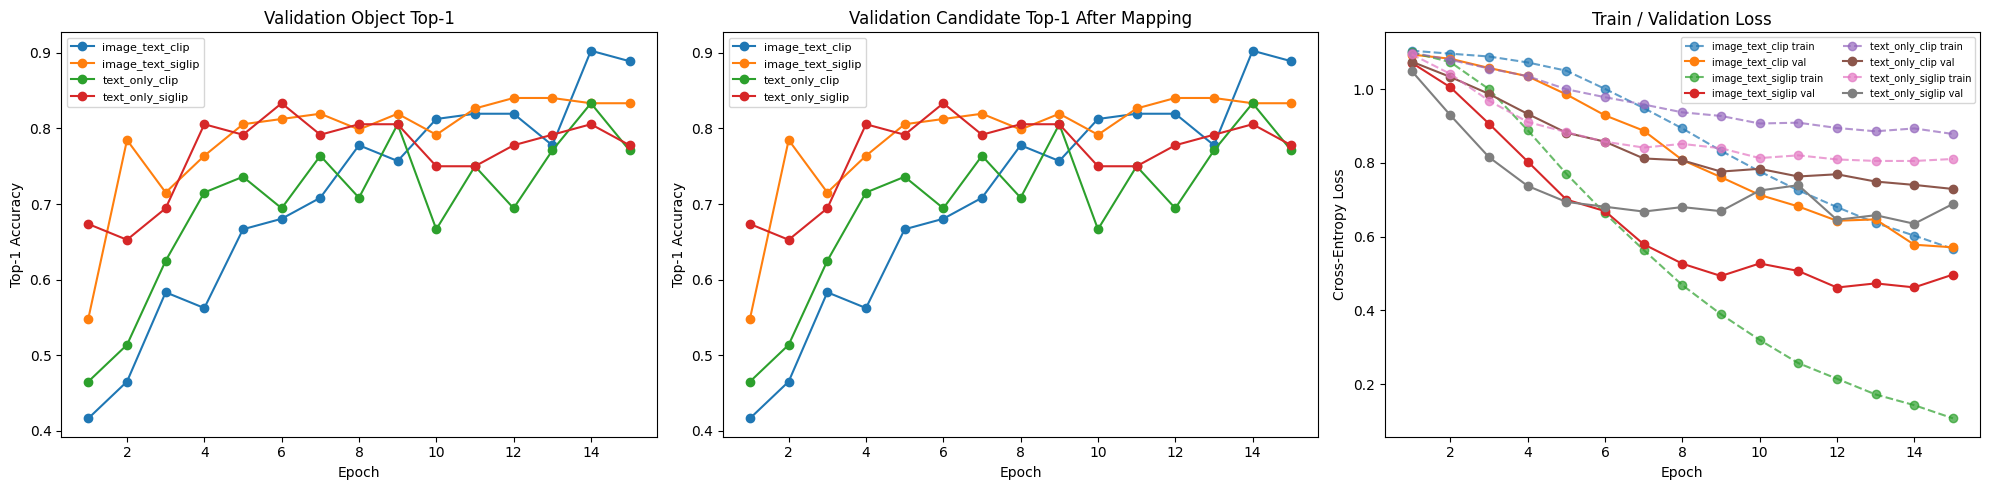

In [36]:
all_history_df = pd.concat([
    clip_text_history_df,
    clip_image_text_history_df,
    siglip_text_history_df,
    siglip_image_text_history_df,
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for model_name, hist in all_history_df.groupby('model'):
    axes[0].plot(hist['epoch'], hist['val_object_top1'], marker='o', label=model_name)
    axes[1].plot(hist['epoch'], hist['val_candidate_top1'], marker='o', label=model_name)
    axes[2].plot(hist['epoch'], hist['train_loss'], marker='o', linestyle='--', alpha=0.7, label=f'{model_name} train')
    axes[2].plot(hist['epoch'], hist['val_loss'], marker='o', label=f'{model_name} val')

axes[0].set_title('Validation Object Top-1')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Top-1 Accuracy')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation Candidate Top-1 After Mapping')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Top-1 Accuracy')
axes[1].legend(fontsize=8)

axes[2].set_title('Train / Validation Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Cross-Entropy Loss')
axes[2].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## How To Read This Notebook

- `val_object_top1` is the real metric for this reformulated task.
- `val_candidate_top1` is the mapped grasp-candidate accuracy after applying:
  - `pickup -> top`
  - `pour -> side`
- The loss plot helps show whether the better model is also training more stably rather than winning from a single lucky epoch.
- If `image_text_*` beats `text_only_*`, that is stronger evidence that the image is helping with spatial grounding.


## Export Deployable CLIP Checkpoint

Run this after the `image_text_clip` experiment to save a runtime checkpoint for ROS fusion.


In [37]:
EXPORT_DIR = PROJECT_ROOT / 'outputs' / 'vlm_object_classifier_runtime'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = EXPORT_DIR / 'image_text_clip_object_classifier.pt'

assert clip_image_text_state_dict is not None, 'clip_image_text_state_dict is None; rerun image_text_clip training first.'

processor = AutoProcessor.from_pretrained(CLIP_MODEL_NAME)
backbone = AutoModel.from_pretrained(CLIP_MODEL_NAME)
dummy = processor(
    images=Image.open(DATA_ROOT / train_records[0]['image_path']).convert('RGB'),
    text=train_records[0]['instruction'],
    return_tensors='pt',
    padding=True,
)
embed_dim = int(get_image_features(backbone, dummy['pixel_values']).shape[-1])

torch.save({
    'model_name': CLIP_MODEL_NAME,
    'embed_dim': embed_dim,
    'classifier_state_dict': clip_image_text_state_dict,
    'num_classes': 3,
    'label_order': ['whole_milk', 'oat_milk', 'soy_milk'],
}, EXPORT_PATH)
print(EXPORT_PATH)


/home/gyanig/catkin_ws/src/tabletop_workspace_opt/outputs/vlm_object_classifier_runtime/image_text_clip_object_classifier.pt
